# Part 1: Construct a KG from unstructured data

This notebook illustrates the internal steps for the implementation of an NLP pipeline for constructing _knowledge graphs_ from unstructured data sources.

## Set up

In [1]:
#from IPython.display import display, HTML, Image, SVG
from collections import defaultdict
from dataclasses import dataclass
import itertools
import os
import typing
import warnings

from gliner_spacy.pipeline import GlinerSpacy
from icecream import ic
from nltk import Tree
from pydantic import BaseModel
from pyinstrument import Profiler
import glirel
import matplotlib
import matplotlib.colors
import networkx as nx
import pandas as pd
import pyvis
import spacy
import transformers

W1112 10:32:21.837000 12348 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Plus a minor workaround for installing the `spaCy` language model

Override specific Hugging Face error messages, since `transformers` and `tokenizers` have noisy logging.

In [2]:
transformers.logging.set_verbosity_error()
os.environ["TOKENIZERS_PARALLELISM"] = "0"

Show a watermark of the OS, hardware, language environment, and dependent library versions.

In [3]:
%load_ext watermark
%watermark
%watermark --iversions

Last updated: 2025-11-12T10:33:31.534762+07:00

Python implementation: CPython
Python version       : 3.11.9
IPython version      : 9.5.0

Compiler    : MSC v.1938 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 154 Stepping 3, GenuineIntel
CPU cores   : 16
Architecture: 64bit

spacy       : 3.8.8
pyvis       : 0.3.2
glirel      : 1.2.1
matplotlib  : 3.10.6
pydantic    : 2.11.9
gliner_spacy: 0.0.11
transformers: 4.51.0
pyinstrument: 5.1.1
nltk        : 3.9.1
networkx    : 3.5
pandas      : 2.3.2



Start the stochastic stack trace profiler.

In [4]:
profiler: Profiler = Profiler()
profiler.start()

Define the model selections and parameter settings.

In [5]:
CHUNK_SIZE: int = 1024

GLINER_MODEL: str = "urchade/gliner_large-v2.1"

NER_LABELS: typing.List[ str] = [
    "Behavior",
    "City",
    "Company",    
    "Condition",
    "Conference",
    "Country",
    "Food",
    "Food Additive",
    "Hospital",
    "Organ",
    "Organization",
    "People Group",
    "Person",
    "Publication",
    "Research",
    "Science",
    "University",
]

RE_LABELS: dict = {
    "glirel_labels": {
        "no_relation": {},  
        "co_founder": {"allowed_head": ["PERSON"], "allowed_tail": ["ORG"]}, 
        "country_of_origin": {"allowed_head": ["PERSON", "ORG"], "allowed_tail": ["LOC", "GPE"]}, 
        "parent": {"allowed_head": ["PERSON"], "allowed_tail": ["PERSON"]}, 
        "followed_by": {"allowed_head": ["PERSON", "ORG"], "allowed_tail": ["PERSON", "ORG"]},  
        "spouse": {"allowed_head": ["PERSON"], "allowed_tail": ["PERSON"]},  
        "child": {"allowed_head": ["PERSON"], "allowed_tail": ["PERSON"]},  
        "founder": {"allowed_head": ["PERSON"], "allowed_tail": ["ORG"]},  
        "headquartered_in": {"allowed_head": ["ORG"], "allowed_tail": ["LOC", "GPE", "FAC"]},  
        "acquired_by": {"allowed_head": ["ORG"], "allowed_tail": ["ORG", "PERSON"]},  
        "subsidiary_of": {"allowed_head": ["ORG"], "allowed_tail": ["ORG", "PERSON"]}, 
    }
}

SPACY_MODEL: str = "en_core_web_md"

STOP_WORDS: typing.Set[ str ] = set([
    "PRON.it",
    "PRON.that",
    "PRON.they",
    "PRON.those",
    "PRON.we",
    "PRON.which",
    "PRON.who",
])

TR_ALPHA: float = 0.85
TR_LOOKBACK: int = 3

Load the models for `spaCy`, `GLiNER`, `GLiREL` -- this may take several minutes when run the first time.

In [6]:
nlp: spacy.Language = spacy.load(SPACY_MODEL)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    nlp.add_pipe(
        "gliner_spacy",
        config = {
            "gliner_model": GLINER_MODEL,
            "labels": NER_LABELS,
            "chunk_size": CHUNK_SIZE,
            "style": "ent",
        },
    )
        
    nlp.add_pipe(
        "glirel",
        after = "ner",
    );

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Define the global data structures -- which need to be reset for every run, not for each chunk iteration.

In [7]:
graph: nx.Graph = nx.Graph()
known_lemma: typing.List[ str ] = []

## Parse one text chunk

Define an input text chunk.

In [8]:
class TextChunk (BaseModel):
    uid: int
    url: str
    text: str
    
SAMPLE_CHUNK: TextChunk = TextChunk(
    uid = 1,
    url = "https://www.theguardian.com/society/article/2024/jul/31/eating-processed-red-meat-could-increase-risk-of-dementia-study-finds",
    text = """
Pembangkit listrik tenaga surya portable adalah pembangkit yang dapat dibawa kemanapun sehingga tidak menghambat kebutuhan akan energi listrik. Selain itu pembangkit listrik tenaga surya portable memiliki bentuk yang mudah dibawa. Energi surya photovoltaic adalah teknologi pemanfaatan energi surya dengan cara mengonversikan energi surya menjadi arus listrik dengan piranti semi konduktor yang disebut sebagai sel surya (solar cell). Penelitian ini dilakukan atas pertimbangan letak geografis Indonesia yang terdapat di garis katulistiwa sehingga energi surya sangat melimpah dan cocok untuk menggunakan pembangkit listrik tenaga surya. Dengan itu maka kita tidak perlu bergantung pada energi listrik dari PLN. Penelitian ini dibuat untuk memenuhi kebutuhan akan energi listrik dan untuk mempermudah menjangkau daerah-daerah yang sulit dijangkau oleh sistem transmisi energi listrik dari PLN. Tujuan dari penelitian ini adalah untuk membuat desain dari alat pembangkit listrik tenaga surya portable dan mengetahui hasil kinerja alat tersebut. Metode penelitian yang digunakan pada penelitian ini adalah menggunakan metode eksperimen (percobaan) Setelah melakukan penelitian dan pengambilan data didapatkan data hasil penchargeran accu sebesar 13.40 V menggunakan accu 10ah. Dan didapat juga hasil pengujian accu selama 6 jam dengan beban 4 buah lampu led 5watt. Kata kunci: Pembangkit Listrik Tenaga Surya Portable, Energi terbarukan, photovoltaic Abstract Portable solar power plants are generators that can be taken anywhere so as not to impede productivity. In addition, portable solar power plants have aÂ â€¦""".strip(),
)

chunk: TextChunk = SAMPLE_CHUNK

Parse the input text.

In [9]:
doc: spacy.tokens.doc.Doc = list(
    nlp.pipe(
        [( chunk.text, RE_LABELS )],
        as_tuples = True,
    )
)[0][0]

Visualize the `spaCy` parse and `GLiNER` _named entity recognition_ results.

In [10]:
def to_nltk_tree (node):
    if node.n_lefts + node.n_rights > 0:
        return Tree(node.orth_, [to_nltk_tree(child) for child in node.children])
    else:
        return node.orth_

[to_nltk_tree(sent.root).pretty_print() for sent in doc.sents]

                                                  dibawa                                                               
  __________________________________________________|______________________________                                     
 |     |    |           pembangkit                                                 |                                   
 |     |    |      _________|_______________                                       |                                    
 |     |    |     |         |             surya                                 listrik                                
 |     |    |     |         |         ______|_______            ___________________|_______________________             
 |     |    |     |         |        |           listrik       |          |        |      |              tidak         
 |     |    |     |         |        |              |          |          |        |      |         _______|______      
yang dapat  .  portable   adalah   t

[None, None, None, None, None, None, None, None, None, None, None, None, None]

## Layer 1: construct a lexical graph

Scan the document tokens to add lemmas to the _textgraph_.

In [11]:
for sent in doc.sents:
    node_seq: typing.List[ int ] = []
    ic(sent)

    for tok in sent:
        text: str = tok.text.strip()
        
        if tok.pos_ in [ "NOUN", "PROPN" ]:
            key: str = tok.pos_ + "." + tok.lemma_.strip().lower()
            print(tok.i, key, tok.text.strip())

            if key not in known_lemma:
                # create a new node
                known_lemma.append(key)
                node_id: int = known_lemma.index(key)
                node_seq.append(node_id)

                graph.add_node(
                    node_id,
                    key = key,
                    kind = "Lemma",
                    pos = tok.pos_,
                    text = text,
                    chunk = chunk.uid,
                    count = 1,
                )
            else:
                # link to an existing node, adding weight
                node_id = known_lemma.index(key)
                node_seq.append(node_id)

                node: dict = graph.nodes[node_id]
                node["count"] += 1

    # create the textrank edges
    ic(node_seq)

    for hop in range(TR_LOOKBACK):
        for node_id, node in enumerate(node_seq[: -1 - hop]):            
            neighbor: int = node_seq[hop + node_id + 1]
            graph.add_edge(
                node,
                neighbor,
                rel = "FOLLOWS_LEXICALLY",
            )

ic| sent: Pembangkit listrik tenaga surya portable adalah pembangkit yang dapat dibawa kemanapun sehingga tidak menghambat kebutuhan akan energi listrik.
ic| node_seq: [0, 1, 2, 3, 4, 5, 0, 6, 7, 8, 9, 10, 11

0 PROPN.pembangkit Pembangkit
1 PROPN.listrik listrik
2 PROPN.tenaga tenaga
3 PROPN.surya surya
4 PROPN.portable portable
5 PROPN.adalah adalah
6 PROPN.pembangkit pembangkit
7 PROPN.yang yang
8 PROPN.dapat dapat
9 PROPN.dibawa dibawa
10 PROPN.kemanapun kemanapun
11 PROPN.sehingga sehingga
12 PROPN.tidak tidak
13 PROPN.menghambat menghambat
14 PROPN.kebutuhan kebutuhan
15 PROPN.akan akan
16 PROPN.energi energi
17 PROPN.listrik listrik


, 12, 13, 14, 15, 1]
ic| sent: Selain itu pembangkit listrik tenaga surya portable memiliki bentuk yang mudah dibawa.
ic| node_seq: [16, 17, 0, 1, 2, 3, 4, 18, 19, 6, 20, 8]


19 PROPN.selain Selain
20 PROPN.itu itu
21 PROPN.pembangkit pembangkit
22 PROPN.listrik listrik
23 PROPN.tenaga tenaga
24 PROPN.surya surya
25 PROPN.portable portable
26 PROPN.memiliki memiliki
27 PROPN.bentuk bentuk
28 PROPN.yang yang
29 PROPN.mudah mudah
30 PROPN.dibawa dibawa


ic| sent: Energi surya photovoltaic adalah teknologi pemanfaatan energi surya dengan cara mengonversikan energi surya menjadi arus listrik dengan piranti semi konduktor yang disebut sebagai sel surya (solar cell).
ic| node_seq: [15,
               3,
               21,
               5,
               22,
               23,
               15,
               3,
               24,
               25,
               26,
               15,
               3,
               27,
               28,
               1,
               24,
               29,
               30,
               6,
               31,
               32,
               33,
               3,

...

183 PROPN.dan Dan
184 PROPN.didapat didapat
185 NOUN.juga juga
186 PROPN.hasil hasil
187 PROPN.pengujian pengujian
188 PROPN.accu accu
189 PROPN.selama selama
191 PROPN.jam jam
192 PROPN.dengan dengan
193 PROPN.beban beban
195 PROPN.buah buah
196 NOUN.lampu lampu
198 PROPN.5watt 5watt



ic| sent: Kata kunci: Pembangkit Listrik Tenaga Surya Portable, Energi terbarukan, photovoltaic Abstract Portable solar power plants are generators that can be taken anywhere so as not to impede productivity.
ic| node_seq: [99, 100, 0, 1, 2, 3, 4, 15, 101, 21, 102, 4, 103, 104, 105, 106]


200 PROPN.kata Kata
201 NOUN.kunci kunci
203 PROPN.pembangkit Pembangkit
204 PROPN.listrik Listrik
205 PROPN.tenaga Tenaga
206 PROPN.surya Surya
207 PROPN.portable Portable
209 PROPN.energi Energi
210 NOUN.terbarukan terbarukan
212 PROPN.photovoltaic photovoltaic
213 PROPN.abstract Abstract
214 PROPN.portable Portable
216 NOUN.power power
217 NOUN.plant plants
219 NOUN.generator generators
230 NOUN.productivity productivity


ic| sent: In addition, portable solar power plants have aÂ â€¦
ic| node_seq: [107, 103, 104, 108, 109]


233 NOUN.addition addition
237 NOUN.power power
238 NOUN.plant plants
240 NOUN.aâ aÂ
243 NOUN.¦ ¦


Keep track of the sentence numbers, which we'll use later for entity co-occurrence links.

In [12]:
sent_map: typing.Dict[ spacy.tokens.span.Span, int ] = {}

for sent_id, sent in enumerate(doc.sents):
    sent_map[sent] = sent_id

## Layer 2: overlay entities onto the graph

Classify spans as potential entities.

Note that if we'd run [_entity resolution_](https://neo4j.com/developer-blog/entity-resolved-knowledge-graphs/) previously from _structured_ or _semi-structured_ data sources to generate a "backbone" for the knowledge graph, then we use the contextualized _surface forms_ from that phase to perform _entity linking_ on the entities extracted here from _unstructured_ data.

In [13]:
@dataclass(order=False, frozen=False)
class Entity:
    loc: typing.Tuple[ int ]
    key: str
    text: str
    label: str
    chunk_id: int
    sent_id: int
    span: spacy.tokens.span.Span
    node: typing.Optional[ int ] = None


span_decoder: typing.Dict[ tuple, Entity ] = {}


def make_entity (
    span: spacy.tokens.span.Span,
    chunk: TextChunk,
    ) -> Entity:
    """
Instantiate one `Entity` dataclass object, adding it to the working "vocabulary".
    """
    key: str = " ".join([
        tok.pos_ + "." + tok.lemma_.strip().lower()
        for tok in span
    ])
    
    ent: Entity = Entity(
        ( span.start, span.end, ),
        key,
        span.text,
        span.label_,
        chunk.uid,
        sent_map[span.sent],
        span,
    )

    if ent.loc not in span_decoder:
        span_decoder[ent.loc] = ent
        ic(ent)

    return ent

In [14]:
for span in doc.ents:
    make_entity(span, chunk)

for span in doc.noun_chunks:
    make_entity(span, chunk)

ic| ent: Entity(loc=(0, 5),
                key='PROPN.pembangkit PROPN.listrik PROPN.tenaga PROPN.surya '
                    'PROPN.portable',
                text='Pembangkit listrik tenaga surya portable',
                label='Organization',
                chunk_id=1,
                sent_id=0,
                span=Pembangkit listrik tenaga surya portable,
                node=None)
ic| ent: Entity(loc=(21, 26),
                key='PROPN.pembangkit PROPN.listrik PROPN.tenaga PROPN.surya '
                    'PROPN.portable',
                text='pembangkit listrik tenaga surya portable',
                label='Organization',
                chunk_id=1,
                sent_id=1,
                span=pembangkit listrik tenaga surya portable,
                node=None)
ic| ent: Entity(loc=(62, 63),
                key='PROPN.penelitian',
                text='Penelitian',
                label='Research',
                chunk_id=1,
                sent_id=3,
                sp

Overlay the inferred entity spans atop the base layer constructed by _textgraph_ analysis of the `spaCy` parse trees.

In [15]:
def extract_entity (
    ent: Entity,
    ) -> None:
    """
Link one `Entity` into the existing graph.
    """
    if ent.key not in known_lemma:
        # add a new Entity node to the graph and link to its component Lemma nodes
        known_lemma.append(ent.key)
        node_id: int = known_lemma.index(ent.key)
        
        graph.add_node(
            node_id,
            key = ent.key,
            kind = "Entity",
            label = ent.label,
            pos = "NP",
            text = ent.text,
            chunk = ent.chunk_id,
            count = 1,
        )

        for tok in ent.span:
            tok_key: str = tok.pos_ + "." + tok.lemma_.strip().lower()

            if tok_key in known_lemma:
                tok_idx: int = known_lemma.index(tok_key)

                graph.add_edge(
                    node_id,
                    tok_idx,
                    rel = "COMPOUND_ELEMENT_OF",
                )
    else:
        node_id: int = known_lemma.index(ent.key)
        node: dict = graph.nodes[node_id]
        # promote to an Entity, in case the node had been a Lemma
        node["kind"] = "Entity"
        node["chunk"] = ent.chunk_id
        node["count"] += 1

        # select the more specific label
        if "label" not in node or node["label"] == "NP":
          node["label"] = ent.label

    ent.node = node_id

In [16]:
for ent in span_decoder.values():
    if ent.key not in STOP_WORDS:
        extract_entity(ent)
        ic(ent)

ic| ent: Entity(loc=(0, 5),
                key='PROPN.pembangkit PROPN.listrik PROPN.tenaga PROPN.surya '
                    'PROPN.portable',
                text='Pembangkit listrik tenaga surya portable',
                label='Organization',
                chunk_id=1,
                sent_id=0,
                span=Pembangkit listrik tenaga surya portable,
                node=110)
ic| ent: Entity(loc=(21, 26),
                key='PROPN.pembangkit PROPN.listrik PROPN.tenaga PROPN.surya '
                    'PROPN.portable',
                text='pembangkit listrik tenaga surya portable',
                label='Organization',
                chunk_id=1,
                sent_id=1,
                span=pembangkit listrik tenaga surya portable,
                node=110)
ic| ent: Entity(loc=(62, 63),
                key='PROPN.penelitian',
                text='Penelitian',
                label='Research',
                chunk_id=1,
                sent_id=3,
                span

Report the relations inferred by `GLiREL`.

In [17]:
relations: typing.List[ dict ] = sorted(
    doc._.relations,
    key = lambda x: x["score"],
    reverse = True,
)

for item in relations:
    src_loc: typing.Tuple[ int ] = tuple(item["head_pos"])
    dst_loc: typing.Tuple[ int ] = tuple(item["tail_pos"])
    skip_rel: bool = False

    if src_loc not in span_decoder:
        print("MISSING src entity:", item["head_text"], item["head_pos"])
        
        src_ent: Entity = make_entity(
            doc[ item["head_pos"][0] : item["head_pos"][1] ],
            chunk,
        )

        if src_ent.key in STOP_WORDS:
            skip_rel = True
        else:
            extract_entity(src_ent)

    if dst_loc not in span_decoder:
        print("MISSING dst entity:", item["tail_text"], item["tail_pos"])

        dst_ent: Entity = make_entity(
            doc[ item["tail_pos"][0] : item["tail_pos"][1] ],
            chunk,
        )

        if dst_ent.key in STOP_WORDS:
            skip_rel = True
        else:
            extract_entity(dst_ent)

    # link the connected nodes
    if not skip_rel:
        src_ent = span_decoder[src_loc]
        dst_ent = span_decoder[dst_loc]

        rel: str = item["label"].strip().replace(" ", "_").upper()
        prob: float = round(item["score"], 3)

        print(f"{src_ent.text} {src_ent.node} -> {rel} -> {dst_ent.text} {dst_ent.node} | {prob}")

        graph.add_edge(
            src_ent.node,
            dst_ent.node,
            rel = rel,
            prob = prob,
        )

Connect the co-occurring entities.

In [18]:
ent_map: typing.Dict[ int, typing.Set[ int ]] = defaultdict(set)

for ent in span_decoder.values():
    if ent.node is not None:
        ent_map[ent.sent_id].add(ent.node)    

for sent_id, nodes in ent_map.items():
    for pair in itertools.combinations(list(nodes), 2):
        if not graph.has_edge(*pair):
            graph.add_edge(
                pair[0],
                pair[1],
                rel = "CO_OCCURS_WITH",
                prob = 1.0,
            )

Run eigenvalue centrality (i.e., _Personalized PageRank_) to rank the entities.

In [19]:
for node, rank in nx.pagerank(graph, alpha = TR_ALPHA, weight = "count").items():
    graph.nodes[node]["rank"] = rank

Report the top-ranked entities extracted from this text chunk.

In [20]:
df: pd.DataFrame = pd.DataFrame([
    node_attr
    for node, node_attr in graph.nodes(data = True)
    if node_attr["kind"] == "Entity"
]).sort_values(by = [ "rank", "count" ], ascending = False)

df.head(20)

,key,kind,pos,text,chunk,count,label,rank
1,PROPN.penelitian,Entity,PROPN,Penelitian,1,12,Research,0.020422
23,PROPN.indonesia PROPN.yang PROPN.terdapat PROP...,Entity,NP,Indonesia yang terdapat di garis katulistiwa s...,1,1,NP,0.014309
25,PROPN.penelitian PROPN.ini PROPN.dibuat PROPN....,Entity,NP,Penelitian ini dibuat untuk memenuhi kebutuhan...,1,1,NP,0.014035
26,PROPN.tujuan PROPN.dari PROPN.penelitian PROPN...,Entity,NP,Tujuan dari penelitian ini adalah untuk membua...,1,1,NP,0.012641
0,PROPN.photovoltaic,Entity,PROPN,photovoltaic,1,3,NP,0.011292
31,PROPN.dan PROPN.didapat NOUN.juga PROPN.hasil ...,Entity,NP,Dan didapat juga hasil pengujian accu selama 6...,1,1,NP,0.010864
6,PROPN.accu,Entity,PROPN,accu,1,4,NP,0.010399
11,PROPN.pembangkit PROPN.listrik PROPN.tenaga PR...,Entity,NP,Pembangkit listrik tenaga surya portable,1,3,Organization,0.009596
16,PROPN.selain PROPN.itu PROPN.pembangkit PROPN....,Entity,NP,Selain itu pembangkit listrik tenaga surya por...,1,1,NP,0.008980
24,PROPN.dengan PROPN.itu PROPN.maka PROPN.kita P...,Entity,NP,Dengan itu maka kita tidak perlu bergantung pa...,1,1,NP,0.008465


## Visualize the results

Use `pyvis` to provide an interactive visualization of both layers of the graph, so far...

In [22]:
pv_net: pyvis.network.Network = pyvis.network.Network(
    height = "750px",
    width = "100%",
    notebook = True,
    cdn_resources = "remote",
)

for node_id, node_attr in graph.nodes(data = True):
    if node_attr["kind"] == "Entity":
        color: str = "hsl(65, 46%, 58%)"
        size: int = round(200 * node_attr["rank"])
    else:
        color = "hsla(72, 10%, 90%, 0.95)"
        size = round(30 * node_attr["rank"])

    pv_net.add_node(
        node_id,
        label = node_attr["text"],
        title = node_attr.get("label"),
        color = color,
        size = size,
    )

for src_node, dst_node, edge_attr in graph.edges(data = True):
    pv_net.add_edge(
        src_node,
        dst_node,
        title = edge_attr.get("rel"),
    )

pv_net.toggle_physics(True)
pv_net.show("chunk.html")

chunk.html


Show a cluster analysis of the _lexical graph_.

In [23]:
communities: typing.Generator = nx.community.louvain_communities(graph)

comm_map: typing.Dict[ int, int ] = {
    node_id: i
    for i, comm in enumerate(communities)
    for node_id in comm
}
                                                                                                                            
xkcd_colors: typing.List[ str ] = list(matplotlib.colors.XKCD_COLORS.values())

colors: typing.List[ str ] = [
    xkcd_colors[comm_map[n]]
    for n in list(graph.nodes())
]
                                                                                                                                         
labels: typing.Dict[ int, str ] = {
    node_id: node_attr["text"]
    for node_id, node_attr in graph.nodes(data = True)
}

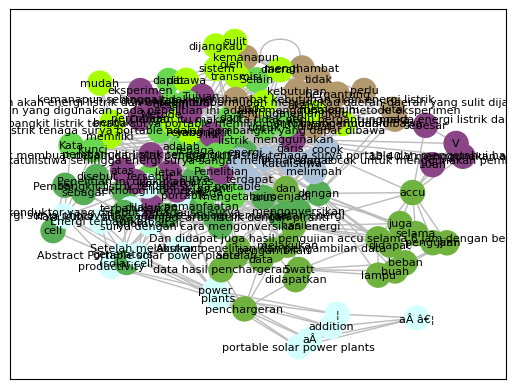

In [24]:
SPRING_DISTANCE: float = 2.5
                                                                                                                                     
nx.draw_networkx(
    graph,
    pos = nx.spring_layout(
        graph,
        k = SPRING_DISTANCE / len(communities),
    ),
    labels = labels,
    node_color = colors,
    edge_color = "#bbb",
    with_labels = True,
    font_size = 8,
)

## Tear down

How much did the global data structures grow?

In [25]:
ic(len(known_lemma))
ic(len(span_decoder))
ic(len(graph.nodes()));

ic| len(known_lemma): 135
ic| len(span_decoder): 45
ic| len(graph.nodes()): 135


Stop the profiler and report the performance measures.

In [26]:
profiler.stop()
profiler.print()


  _     ._   __/__   _ _  _  _ _/_   Recorded: 10:33:34  Samples:  38954
 /_//_/// /_\ / //_// / //_'/ //     Duration: 1400.785  CPU time: 146.906
/   _/                      v5.1.1

Profile at C:\Users\rizky\AppData\Local\Temp\ipykernel_12348\382364451.py:2

1400.782 MainThread  <thread>:26020
└─ 1398.462 _run_module_as_main  <frozen runpy>:173
      [21 frames hidden]  <frozen runpy>, ipykernel_launcher, t...
         1273.192 select  <built-in>
         123.037 ZMQInteractiveShell.run_ast_nodes  IPython\core\interactiveshell.py:3540
         ├─ 78.667 <module>  ..\..\..\..\Temp\ipykernel_12348\2312294158.py:1
         │  └─ 75.893 English.add_pipe  spacy\language.py:768
         │     └─ 75.872 English.create_pipe  spacy\language.py:656
         │        └─ 75.785 registry.resolve  confection\__init__.py:751
         │           └─ 75.785 registry._make  confection\__init__.py:779
         │              └─ 75.777 registry._fill  confection\__init__.py:826
         │              

## Quality checks

Are there any prounoun lemmas that we need to add to the `STOP_WORDS` list? Until we have a good _coreference_ stage in this workflow, the pronouns are too generic and tend to distort the graph results. NB: compound references are "contained" and not a problem.

In [26]:
for x in known_lemma:
    if "PRON" in x:
        print(x)

PRON.something
PRON.another


Which nodes should we promote to the next level?

In [27]:
kept_nodes: typing.Set[ int ] = set()

for node_id, node_attr in graph.nodes(data = True):
    if node_attr["kind"] == "Entity":
        print(node_id, node_attr["key"], node_attr["rank"], node_attr["label"], node_attr["text"], node_attr["chunk"])
        kept_nodes.add(node_id)

21 PROPN.photovoltaic 0.01129163895007467 NP photovoltaic 1
35 PROPN.penelitian 0.020422458627360765 Research Penelitian 1
39 PROPN.letak 0.007215837387374112 NP letak 1
40 PROPN.indonesia 0.007290605764470521 Country Indonesia 1
57 PROPN.pln 0.004509587443751889 Organization PLN 1
79 NOUN.percobaan 0.004293955570498605 NP percobaan 1
86 PROPN.accu 0.01039930607448005 NP accu 1
98 PROPN.5watt 0.004263324404490955 NP 5watt 1
105 NOUN.generator 0.007062213022426752 NP generators 1
106 NOUN.productivity 0.006476692288386284 Behavior productivity 1
107 NOUN.addition 0.005628631562711279 NP addition 1
110 PROPN.pembangkit PROPN.listrik PROPN.tenaga PROPN.surya PROPN.portable 0.009596233623558117 Organization Pembangkit listrik tenaga surya portable 1
111 PROPN.pembangkit PROPN.listrik PROPN.tenaga PROPN.surya 0.006314769175318625 Organization pembangkit listrik tenaga surya 1
112 PROPN.energi NOUN.terbarukan 0.006212340331463191 Organization Energi terbarukan 1
113 PROPN.pembangkit PROPN.li

Which edges should we promote to the next level?

In [28]:
skip_rel: typing.Set[ str ] = set([ "FOLLOWS_LEXICALLY", "COMPOUND_ELEMENT_OF" ])

for src_id, dst_id, edge_attr in graph.edges(data = True):
    if src_id in kept_nodes and dst_id in kept_nodes:
        rel: str = edge_attr["rel"]

        if rel not in skip_rel:
            print(src_id, dst_id, rel, edge_attr["prob"])

0 4 CO_OCCURS_WITH 1.0
0 74 CO_OCCURS_WITH 1.0
0 75 CO_OCCURS_WITH 1.0
0 76 CO_OCCURS_WITH 1.0
1 74 CO_OCCURS_WITH 1.0
1 75 CO_OCCURS_WITH 1.0
1 76 CO_OCCURS_WITH 1.0
1 68 CO_OCCURS_WITH 1.0
1 79 CO_OCCURS_WITH 1.0
4 74 CO_OCCURS_WITH 1.0
4 75 CO_OCCURS_WITH 1.0
4 77 CO_OCCURS_WITH 1.0
4 68 CO_OCCURS_WITH 1.0
4 12 CO_OCCURS_WITH 1.0
4 79 CO_OCCURS_WITH 1.0
12 68 CO_OCCURS_WITH 1.0
12 76 CO_OCCURS_WITH 1.0
12 79 CO_OCCURS_WITH 1.0
12 69 CO_OCCURS_WITH 1.0
12 70 CO_OCCURS_WITH 1.0
12 80 CO_OCCURS_WITH 1.0
12 81 CO_OCCURS_WITH 1.0
12 82 CO_OCCURS_WITH 1.0
12 83 CO_OCCURS_WITH 1.0
12 18 CO_OCCURS_WITH 1.0
12 84 CO_OCCURS_WITH 1.0
12 85 CO_OCCURS_WITH 1.0
12 71 CO_OCCURS_WITH 1.0
12 72 CO_OCCURS_WITH 1.0
12 93 CO_OCCURS_WITH 1.0
12 30 CO_OCCURS_WITH 1.0
12 96 CO_OCCURS_WITH 1.0
12 97 CO_OCCURS_WITH 1.0
12 87 CO_OCCURS_WITH 1.0
12 94 CO_OCCURS_WITH 1.0
12 105 CO_OCCURS_WITH 1.0
12 106 CO_OCCURS_WITH 1.0
12 107 CO_OCCURS_WITH 1.0
12 108 CO_OCCURS_WITH 1.0
12 51 CO_OCCURS_WITH 1.0
18 69 CO_OCC